In [57]:
from pymodis.convertmodis_gdal import convertModisGDAL
import os
import numpy as np
from osgeo import gdal
import rioxarray
from satpy import Scene
import matplotlib.pyplot as plt
import autoroot
import xarray as xr
from rs_tools._src.geoprocessing.modis.rescale import convert_integers2radiances
from mpl_toolkits.basemap import Basemap, cm
from scipy.interpolate import griddata
import rasterio

In [50]:
def interp_coords(lat: np.array, lon: np.array, desired_size: tuple=(2030, 1354)) -> np.array:
    # Create grid coordinates for the original and interpolated arrays
    original_rows = np.stack((np.linspace(0, lat.shape[0], num=lat.shape[0]),) * lat.shape[1], axis=1)
    original_cols = np.stack((np.linspace(0, lat.shape[1], num=lat.shape[1]),) * lat.shape[0], axis=0)
    sf_x = desired_size[0]/lat.shape[0]
    sf_y = desired_size[1]/lat.shape[1]
    original_rows = (original_rows) * sf_x
    original_cols = (original_cols) * sf_y
    interp_rows, interp_cols = np.indices(desired_size)

    # Flatten the original array and grid coordinates
    original_positions = np.column_stack((original_rows.flatten(), original_cols.flatten()))
    original_lat = lat.values.flatten()
    original_lon = lon.values.flatten()

    interp_positions = np.column_stack((interp_rows.flatten(), interp_cols.flatten()))

    # Perform 2D interpolation using griddata
    interp_lat = griddata(original_positions, original_lat, interp_positions, method='cubic')
    interp_lon = griddata(original_positions, original_lon, interp_positions, method='cubic')

    # Reshape the interpolated array to the desired size
    interp_lat = interp_lat.reshape(desired_size)
    interp_lon = interp_lon.reshape(desired_size)

    return interp_lat, interp_lon
def get_corner_coords(lat_0, lon_0, lat, lon):
    m1 = Basemap(projection='ortho',lon_0=lon_0,lat_0=lat_0,resolution=None)

    xpt0, ypt0 = m1(lon_0,lat_0) # x/y map projection coordinates (in meters)

    xpt1, ypt1 = m1(lon[0,0],lat[0,0]) 
    xpt2, ypt2 = m1(lon[0,-1],lat[0,-1]) 
    xpt3, ypt3 = m1(lon[-1,-1], \
                    lat[-1,-1])
    xpt4, ypt4 = m1(lon[-1,0],lat[-1,0])

    llx = min(xpt1,xpt2,xpt3,xpt4) - xpt0  # lower left
    lly = min(ypt1,ypt2,ypt3,ypt4) - ypt0

    urx = max(xpt1,xpt2,xpt3,xpt4) - xpt0  # upper right
    ury = max(ypt1,ypt2,ypt3,ypt4) - ypt0

    return (llx, lly, urx, ury)
def get_central_coords(lat, lon):

    lat_max = lat[0,0]
    lat_min = lat[-1,-1]

    lat_0 = lat_min + (lat_max - lat_min) / 2.

    long_min = min(lon[0,0],lon[-1,-1])
    long_max = max(lon[0,0],lon[-1,-1])

    lon_0 = long_min + (long_max - long_min) / 2.

    return lat_0, lon_0

In [4]:
files = ['/mnt/data8tb/fire_detection/modis/L1b/MOD021KM.A2023219.0835.061.2023220144500.hdf']
scn = Scene(reader='modis_l1b', filenames=[files[0]])

In [5]:
datasets = scn.available_dataset_names()
datasets

['1',
 '10',
 '11',
 '12',
 '13hi',
 '13lo',
 '14hi',
 '14lo',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'latitude',
 'longitude',
 'satellite_azimuth_angle',
 'satellite_zenith_angle',
 'solar_azimuth_angle',
 'solar_zenith_angle']

In [10]:
ds = xr.open_dataset('/mnt/data8tb/fire_detection/modis/L1b/MOD021KM.A2023219.0835.061.2023220144500.hdf', engine='netcdf4')
ds_2 = scn.to_xarray()

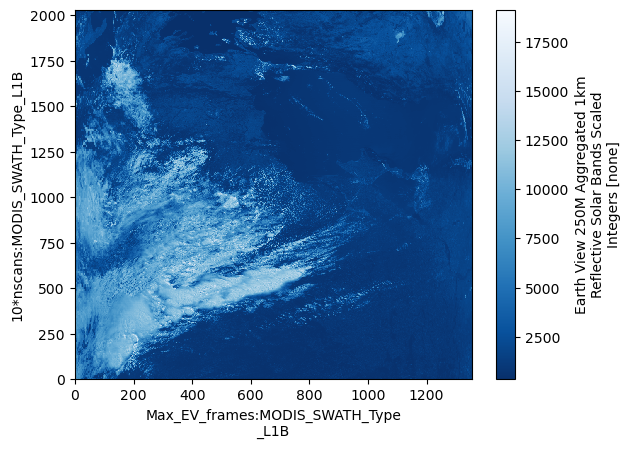

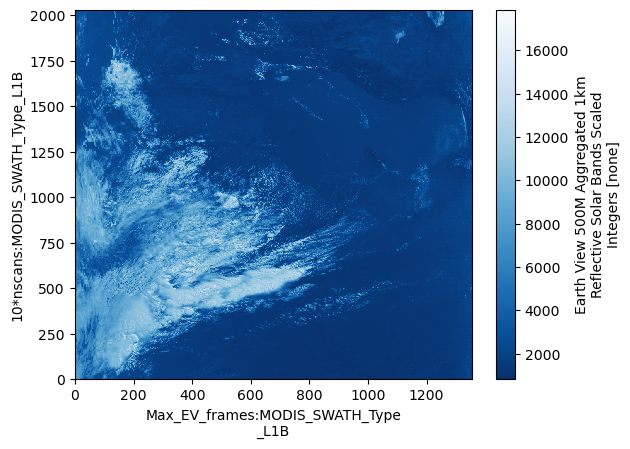

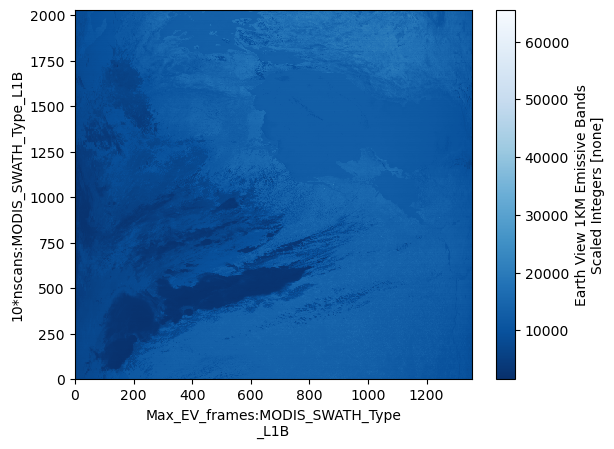

In [11]:
plt.figure()
ds.EV_250_Aggr1km_RefSB[0].plot(cmap='Blues_r') # band 1
plt.figure()
ds.EV_500_Aggr1km_RefSB[0].plot(cmap='Blues_r') # band 3
plt.figure()
ds.EV_1KM_Emissive[5].plot(cmap='Blues_r') # band 25

In [12]:
print('Shape of Lat/Lon coords: ', ds.Latitude.shape)
print('Shape of data: ', ds.EV_250_Aggr1km_RefSB[0].shape)

Shape of Lat/Lon coords:  (406, 271)
Shape of data:  (2030, 1354)


In [13]:
ds_fire = xr.open_dataset('/mnt/data8tb/fire_detection/modis/AF/MOD14.A2023219.0835.061.2023220113415.hdf', engine='netcdf4')


In [81]:
filenames = ['/mnt/data8tb/fire_detection/modis/CM/MOD35_L2.A2023219.0835.061.2023220144656.hdf']
scn = Scene(reader='modis_l2', filenames=[filenames[0]])

In [83]:
scn.available_dataset_names()

['cloud_mask', 'latitude', 'longitude', 'quality_assurance']

In [85]:
scn.available_dataset_names()
#get cloud mask
scn.load(['cloud_mask'])
scn.load(['latitude', 'longitude'])
cloud_mask = scn['cloud_mask']
latitudes_cm = scn['latitude']
longitudes_cm = scn['longitude']

In [23]:
ds_fire['fire mask'].values

array([[4, 4, 4, ..., 5, 5, 5],
       [4, 4, 4, ..., 5, 5, 5],
       [4, 4, 4, ..., 5, 5, 5],
       ...,
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5]], dtype=uint8)

In [25]:
ds['fire'] = ds_fire['fire mask']

In [31]:
lat = ds.Latitude
lon = ds.Longitude

data = ds.EV_1KM_Emissive
corrected_data = convert_integers2radiances(data)

along_track = corrected_data.shape[0]
cross_trak = corrected_data.shape[1]

In [33]:
data_fire = ds['fire']

In [32]:
data

<xarray.DataArray 'EV_1KM_Emissive' (
                                     Band_1KM_Emissive:MODIS_SWATH_Type_L1B: 16,
                                     10*nscans:MODIS_SWATH_Type_L1B: 2030,
                                     Max_EV_frames:MODIS_SWATH_Type_L1B: 1354)> Size: 176MB
array([[[11612., 11629., ..., 14295., 16735.],
        [11926., 11820., ..., 16107., 15276.],
        ...,
        [ 9547.,  9522., ..., 20959., 20292.],
        [10058., 10172., ..., 22442., 21486.]],

       [[ 2914.,  2914., ...,  3035.,  3072.],
        [ 2897.,  2902., ...,  3061.,  3045.],
        ...,
        [ 2913.,  2932., ...,  3178.,  3159.],
        [ 2915.,  2932., ...,  3189.,  3172.]],

       ...,

       [[21320., 21280., ..., 20792., 20759.],
        [21537., 21225., ..., 20844., 20666.],
        ...,
        [20909., 21106., ..., 21350., 21349.],
        [20957., 21056., ..., 21279., 21234.]],

       [[25245., 24895., ..., 24184., 24055.],
        [24918., 24840., ..., 23451., 23846.],
        ...,
        [23789., 23789., ..., 22826., 23063.],
        [23521., 23296., ..., 23021., 23004.]]], dtype=float32)
Dimensions without coordinates: Band_1KM_Emissive:MODIS_SWATH_Type_L1B,
                                10*nscans:MODIS_SWATH_Type_L1B,
                                Max_EV_frames:MODIS_SWATH_Type_L1B
Attributes:
    long_name:         Earth View 1KM Emissive Bands Scaled Integers
    units:             none
    valid_range:       [    0 32767]
    band_names:        20,21,22,23,24,25,27,28,29,30,31,32,33,34,35,36
    radiance_scales:   [6.2623985e-05 3.1495101e-03 6.9215974e-05 7.9103978e-...
    radiance_offsets:  [2730.5835 2730.5835 2730.5835 2730.5835 1077.4448 156...
    radiance_units:    Watts/m^2/micrometer/steradian

In [35]:
#merge data and data_fire
merged = xr.merge([corrected_data, data_fire])

In [42]:
merged

<xarray.Dataset> Size: 179MB
Dimensions:          (Band_1KM_Emissive:MODIS_SWATH_Type_L1B: 16,
                      10*nscans:MODIS_SWATH_Type_L1B: 2030,
                      Max_EV_frames:MODIS_SWATH_Type_L1B: 1354,
                      number_of_scan_lines: 2030, pixels_per_scan_line: 1354)
Dimensions without coordinates: Band_1KM_Emissive:MODIS_SWATH_Type_L1B,
                                10*nscans:MODIS_SWATH_Type_L1B,
                                Max_EV_frames:MODIS_SWATH_Type_L1B,
                                number_of_scan_lines, pixels_per_scan_line
Data variables:
    EV_1KM_Emissive  (Band_1KM_Emissive:MODIS_SWATH_Type_L1B, 10*nscans:MODIS_SWATH_Type_L1B, Max_EV_frames:MODIS_SWATH_Type_L1B) float32 176MB ...
    fire             (number_of_scan_lines, pixels_per_scan_line) uint8 3MB 4...

In [36]:
lat_max = lat[0,0]
lat_min = lat[-1,-1]

lat_0 = lat_min + (lat_max - lat_min) / 2.

long_min = min(lon[0,0],lon[-1,-1])
long_max = max(lon[0,0],lon[-1,-1])

lon_0 = long_min + (long_max - long_min) / 2.

In [40]:
m1 = Basemap(projection='ortho',lon_0=lon_0,lat_0=lat_0,resolution=None)

xpt0, ypt0 = m1(lon_0,lat_0) # x/y map projection coordinates (in meters)

xpt1, ypt1 = m1(lon[0,0],lat[0,0]) 
xpt2, ypt2 = m1(lon[0,-1],lat[0,-1]) 
xpt3, ypt3 = m1(lon[-1,-1], \
                lat[-1,-1])
xpt4, ypt4 = m1(lon[-1,0],lat[-1,0])

llx = min(xpt1,xpt2,xpt3,xpt4) - xpt0  # lower left
lly = min(ypt1,ypt2,ypt3,ypt4) - ypt0

urx = max(xpt1,xpt2,xpt3,xpt4) - xpt0  # upper right
ury = max(ypt1,ypt2,ypt3,ypt4) - ypt0

In [60]:
interp_lat.shape

(2030, 1354)

/tmp/ipykernel_866420/3941543402.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m.pcolormesh(lons, lats, merged.fire, shading='auto')


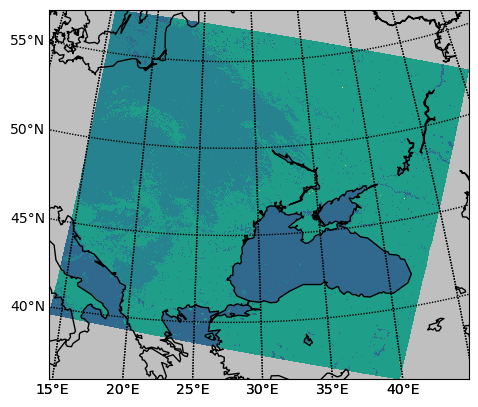

In [54]:
fig = plt.figure()

ax = fig.add_subplot(111)

ax.patch.set_facecolor((0.75,0.75,0.75))

interp_lat, interp_lon = interp_coords(lat, lon)
lat_0, lon_0 = get_central_coords(interp_lat, interp_lon)
llx, lly, urx, ury = get_corner_coords(lat_0, lon_0, interp_lat, interp_lon)

m = Basemap(projection='ortho',lon_0=lon_0,lat_0=lat_0,resolution='l',\
    llcrnrx=llx,llcrnry=lly,urcrnrx=urx,urcrnry=ury) # needed to zoom into area of interest

lons, lats = m(interp_lon, interp_lat)

m.pcolormesh(lons, lats, merged.fire, shading='auto')

m.drawcoastlines()

m.drawparallels(np.arange(-90.,90.,5.), color='k', labels=[True,False,False,False])
m.drawmeridians(np.arange(0.,420.,5.), color='k', labels=[False,False,False,True])

plt.show()

In [64]:
from rasterio.transform import from_bounds

# Flatten the coordinates and fire data
points = np.array([interp_lon.flatten(), interp_lat.flatten()]).T
values = merged.fire.values.flatten()

# Create a regular grid for interpolation
num_x, num_y = 1000, 1000  # Resolution of the grid
lon_min, lon_max = np.min(interp_lon), np.max(interp_lon)
lat_min, lat_max = np.min(interp_lat), np.max(interp_lat)

grid_x, grid_y = np.meshgrid(
    np.linspace(lon_min, lon_max, num_x),
    np.linspace(lat_min, lat_max, num_y)
)

# Interpolate the data onto the regular grid
grid_fire = griddata(points, values, (grid_x, grid_y), method='linear')

# ** Flip the data to correct the vertical orientation **
grid_fire = np.flipud(grid_fire)

# Define the transform for the new grid
transform = from_bounds(lon_min, lat_min, lon_max, lat_max, num_x, num_y)

# Save the interpolated fire data as GeoTIFF
output_file = "fire_plot_interpolated_corrected.tif"

with rasterio.open(
    output_file,
    'w',
    driver='GTiff',
    height=grid_fire.shape[0],
    width=grid_fire.shape[1],
    count=1,
    dtype=grid_fire.dtype,
    crs="EPSG:4326",
    transform=transform,
) as dst:
    dst.write(grid_fire, 1)

print(f"Saved corrected GeoTIFF to {output_file}")

Saved corrected GeoTIFF to fire_plot_interpolated_corrected.tif


## AF

In [30]:
lats = [57.5500138481416, 52.4562786518843, 35.7315422944163, 39.2293844466354]
lons = [14.8180171992672, 50.9482201946203, 40.2986081746735, 13.9823676638156]

min_lat, max_lat = min(lats), max(lats)
min_lon, max_lon = min(lons), max(lons)
print(f"Bounding Box: ({min_lon}, {max_lat}, {max_lon}, {min_lat})")

Bounding Box: (13.9823676638156, 57.5500138481416, 50.9482201946203, 35.7315422944163)


In [31]:

input_file = 'HDF4_SDS:UNKNOWN:"/mnt/data8tb/fire_detection/modis/AF/MOD14.A2023219.0835.061.2023220113415.hdf":0'
output_file = 'output_georef.tif'

# Replace with computed bounds
gdal.Translate(output_file, input_file,
               outputSRS='EPSG:4326',
               outputBounds=(13.9823676638156, 57.5500138481416, 50.9482201946203, 35.7315422944163))

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7af474211c50> >

## CM

In [32]:
lats = [39.0421251324315, 35.2920989444847, 51.8061596264563, 57.3554912821968]
lons = [13.1745246672796, -13.0293237354823, -24.3106705018673, 11.2999497381683]

min_lat, max_lat = min(lats), max(lats)
min_lon, max_lon = min(lons), max(lons)
print(f"Bounding Box: ({min_lon}, {max_lat}, {max_lon}, {min_lat})")

Bounding Box: (-24.3106705018673, 57.3554912821968, 13.1745246672796, 35.2920989444847)


In [35]:
input_file = 'HDF4_EOS:EOS_SWATH:"/mnt/data8tb/fire_detection/modis/CM/MYD35_L2.A2023152.1325.061.2023153174714.hdf":mod35:Cloud_Mask'
output_file = 'output_georef_cm.tif'
gdal.Translate(output_file, input_file,
               outputSRS='EPSG:4326',
               outputBounds=(-24.3106705018673, 57.3554912821968, 13.1745246672796, 35.2920989444847))

Warning 1: output_georef_cm.tif: A geotransform previously set is going to be cleared due to the setting of GCPs.


<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7af39e68fc90> >

In [97]:
#open mod021 with gdal
ds = gdal.Open('/mnt/data8tb/fire_detection/modis/L1b/MOD021KM.A2023219.0835.061.2023220144500.hdf')
ds.GetSubDatasets()


[('HDF4_EOS:EOS_SWATH:"/mnt/data8tb/fire_detection/modis/L1b/MOD021KM.A2023219.0835.061.2023220144500.hdf":MODIS_SWATH_Type_L1B:EV_1KM_RefSB',
  '[15x2030x1354] EV_1KM_RefSB MODIS_SWATH_Type_L1B (16-bit unsigned integer)'),
 ('HDF4_EOS:EOS_SWATH:"/mnt/data8tb/fire_detection/modis/L1b/MOD021KM.A2023219.0835.061.2023220144500.hdf":MODIS_SWATH_Type_L1B:EV_1KM_RefSB_Uncert_Indexes',
  '[15x2030x1354] EV_1KM_RefSB_Uncert_Indexes MODIS_SWATH_Type_L1B (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_SWATH:"/mnt/data8tb/fire_detection/modis/L1b/MOD021KM.A2023219.0835.061.2023220144500.hdf":MODIS_SWATH_Type_L1B:EV_1KM_Emissive',
  '[16x2030x1354] EV_1KM_Emissive MODIS_SWATH_Type_L1B (16-bit unsigned integer)'),
 ('HDF4_EOS:EOS_SWATH:"/mnt/data8tb/fire_detection/modis/L1b/MOD021KM.A2023219.0835.061.2023220144500.hdf":MODIS_SWATH_Type_L1B:EV_1KM_Emissive_Uncert_Indexes',
  '[16x2030x1354] EV_1KM_Emissive_Uncert_Indexes MODIS_SWATH_Type_L1B (8-bit unsigned integer)'),
 ('HDF4_EOS:EOS_SWATH:"/mnt/data8t

In [93]:
#warp the first subdataset to geotiff with gdal to 4326
ds = gdal.Warp('output_georef.tif', ds.GetSubDatasets()[0][0], dstSRS='EPSG:4326')

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7d923b452e80> >

In [94]:
#open the fire mask with gdal
ds_fire = gdal.Open('/mnt/data8tb/fire_detection/modis/AF/MOD14.A2023219.0835.061.2023220113415.hdf')

In [95]:
#warpt the fire mask to geotiff with gdal to 4326 using lat/lon from mod021
#get output bounds from ds of mod021
outputBounds_ = ds.GetGeoTransform()

ds_fire = gdal.Warp('output_georef_fire.tif', ds_fire.GetSubDatasets()[0][0], dstSRS='EPSG:4326', outputBounds=outputBounds_)

RuntimeError: Unable to compute a transformation between pixel/line and georeferenced coordinates for HDF4_SDS:UNKNOWN:"/mnt/data8tb/fire_detection/modis/AF/MOD14.A2023219.0835.061.2023220113415.hdf":0. There is no affine transformation and no GCPs. Specify transformation option SRC_METHOD=NO_GEOTRANSFORM to bypass this check.

In [109]:
from pyhdf.SD import SD, SDC 
import pandas as pd
import cartopy.crs as ccrs

MODIS_File = '/mnt/data8tb/fire_detection/modis/AF/MOD14.A2023219.0835.061.2023220113415.hdf'

df = pd.DataFrame()

f = SD(MODIS_File, SDC.READ)

sds_obj = f.select('fire mask') # select sds

fm_data = sds_obj.get() # get sds data

if fm_data[ fm_data > 6 ].shape[0] > 0:

    for key in ['FP_latitude', 
                    'FP_longitude', 
                    'FP_ViewZenAng',
                    'FP_power']:

        sds_obj = f.select(key) # select sds
        
        data = sds_obj.get() # 
        df[key] = data.ravel() 

/home/sgirtsou/miniconda3/envs/rs_tools/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


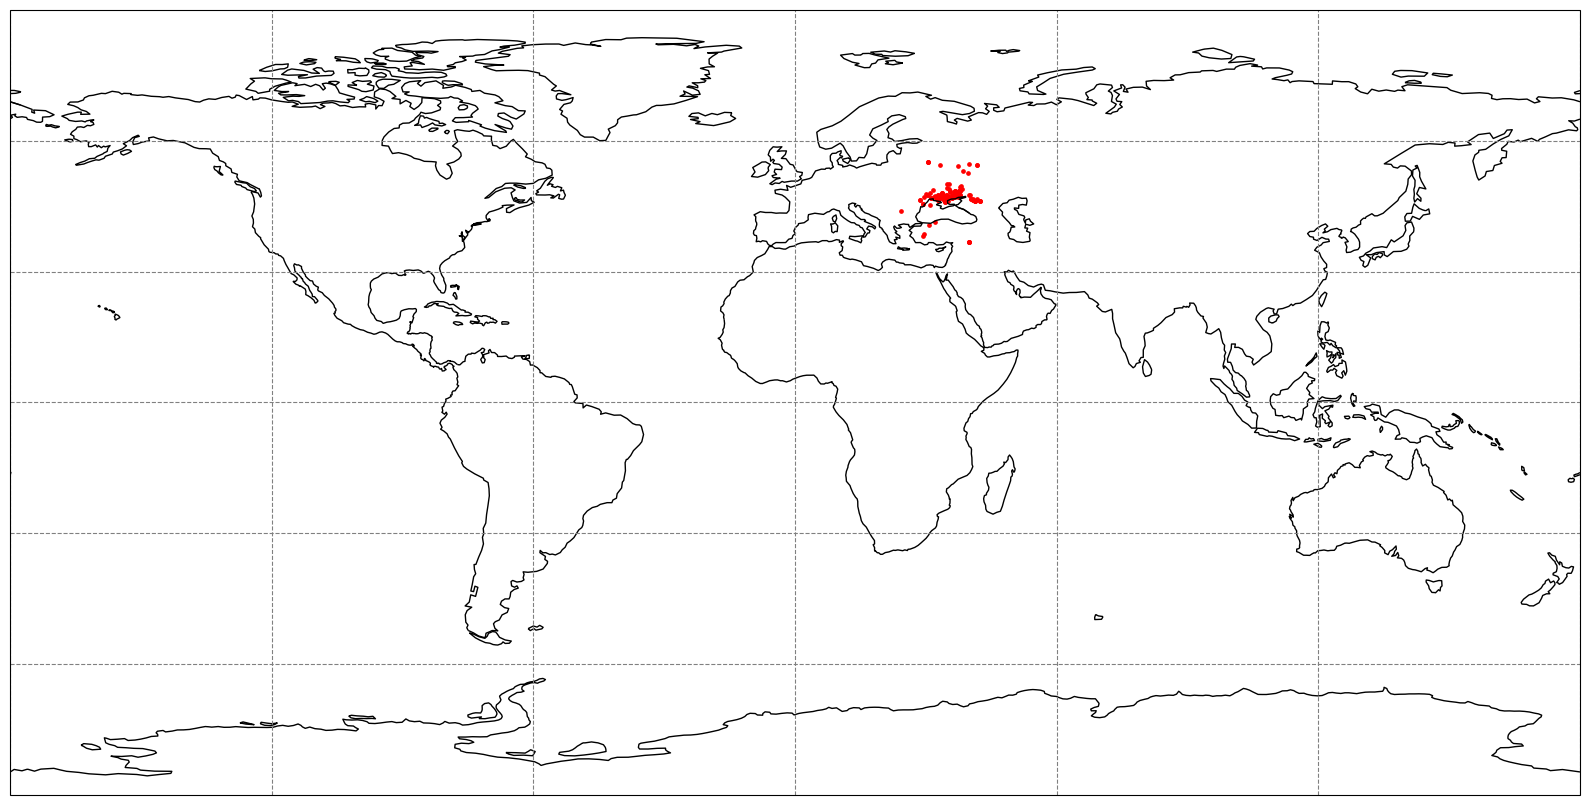

In [105]:
plt.figure(figsize=(16,9))

proj = ccrs.PlateCarree()

ease_extent = [-180., 180., 90., -90.]

ax = plt.axes(projection=proj)

ax.set_extent(ease_extent, crs=proj) 

ax.gridlines(color='gray', linestyle='--')

ax.coastlines()

longs = df['FP_longitude']
lats = df['FP_latitude']

plt.scatter( longs, lats,
         color='red', linewidth=2, marker='o', s=2,
         transform=ccrs.PlateCarree(),
         )

#plt.title('({}) VIIRS AF IBands {}-{}-{} / FP_PersistentAnomalyCategory = {} ({})'.format(platform,year,month,day,PersistentAnomalyCategory,FP_PersistentAnomalyCategory_Legend[PersistentAnomalyCategory]),fontsize=16)

plt.tight_layout()

#plt.savefig('./outputs/{}_AF_Iband_PAC_{}_2022_07_08.png'.format(platform,PersistentAnomalyCategory), dpi=150, facecolor='white')

plt.show()

plt.close()


In [119]:
# Initialize the HDF handler
f = SD(MODIS_File, SDC.READ)

# Read fire mask dataset
fire_mask = f.select('fire mask').get()
fire_indices = (fire_mask >= 7)
latitudes = f.select('FP_latitude').get()
longitudes = f.select('FP_longitude').get()

In [122]:
np.sum(fire_indices)

126

In [114]:
longitudes.shape

(126,)

In [117]:
np.unique(fire_mask)

array([0, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)